# Multi-Agent Investment Research System

### AAI-520: Natural Language Processing and Generative AI  
### Final Team Project - Group 10

**Team Members:**  
Emma Bishop  
Pravin Suranthiran  

**University of San Diego**  
**Fall 2026**

## 1. Environment Setup

In this section, we install and import the Python libraries needed for data loading, preprocessing, sentiment analysis, evaluation, and market-data retrieval.

In [1]:
%pip install --upgrade pandas numpy datasets scikit-learn matplotlib seaborn yfinance requests urllib3 charset-normalizer

  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
  Using cached numpy-2.2.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 16.1 MB/s eta 0:00:0000:010:01
Using cached datasets-5.0.1-py3-none-any.whl (559 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 18.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 22.4 MB/s eta 0:00:00a 0:00:01
Using cached numpy-2.2.6-cp312-cp312-macosx_14_0_arm64.whl (5.1 MB)
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.2.2
    Uninstalling urllib3-2.2.2:
      Successfully uninstalled urllib3-2.2.2
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: charset-normalizer━━━━━━━━━━━━━━━━━━━━━━━━ 2/9 [narwhals]
    Found existing installation: charset-normalizer 3.3.2━━━━━ 2/9 [narwhals]
    Unins

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"yfinance version: {yf.__version__}")
print("Environment setup is complete.")

Pandas version: 3.0.6
NumPy version: 2.0.2
yfinance version: 1.7.0
Environment setup is complete.


In [4]:
%pip install numpy==2.0.2 protobuf==4.25.8

  Using cached numpy-2.0.2-cp312-cp312-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached protobuf-4.25.8-cp37-abi3-macosx_10_9_universal2.whl.metadata (541 bytes)
Using cached numpy-2.0.2-cp312-cp312-macosx_14_0_arm64.whl (5.0 MB)
Using cached protobuf-4.25.8-cp37-abi3-macosx_10_9_universal2.whl (394 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.1
    Uninstalling protobuf-6.33.1:
      Successfully uninstalled protobuf-6.33.1
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numpy]32m1/2 [numpy]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 4.25.8 which is incompatible.
langchain-google-genai 1.0.7 requires

In [5]:
%pip install datasets==3.6.0

  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
Using cached datasets-3.6.0-py3-none-any.whl (491 kB)
  Attempting uninstall: datasets
    Found existing installation: datasets 5.0.1
    Uninstalling datasets-5.0.1:
      Successfully uninstalled datasets-5.0.1

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install huggingface_hub==0.25.2

  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.33.0
    Uninstalling huggingface_hub-1.33.0:
      Successfully uninstalled huggingface_hub-1.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 6.1.0 requires huggingface-hub<2.0.0,>=1.3.0, but you have huggingface-hub 0.25.2 which is incompatible.
langchain-huggingface 1.2.2 requires huggingface-hub<2.0.0,>=0.33.4, but you have huggingface-hub 0.25.2 which is incompatible.
transformers 5.17.0 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.25.2 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Data Collection

We use multiple financial data sources to support the agents in our investment research system. We begin by loading the Financial PhraseBank dataset, which contains financial sentences labeled as positive, neutral, or negative. We will use it to develop and evaluate the sentiment-analysis component of our system.

In [2]:
phrasebank = load_dataset(
    "takala/financial_phrasebank",
    "sentences_allagree",
    trust_remote_code=True
)

print(phrasebank)

FinancialPhraseBank-v1.0.zip:   0%|          | 0.00/682k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2264 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})


In [3]:
# Convert the dataset into a pandas DataFrame
phrasebank_df = phrasebank["train"].to_pandas()

# Convert numerical labels into sentiment names
label_names = phrasebank["train"].features["label"].names
phrasebank_df["sentiment"] = phrasebank_df["label"].map(
    dict(enumerate(label_names))
)

print(f"Dataset shape: {phrasebank_df.shape}")
display(phrasebank_df.head())

Dataset shape: (2264, 3)


,sentence,label,sentiment
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .",1,neutral
1,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zer...",2,positive
2,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .",2,positive
3,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales .,2,positive
4,"Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales .",2,positive


### 2.1 Sentiment Distribution

We examine the distribution of sentiment labels to identify any class imbalance that could affect the performance and evaluation of our sentiment-analysis component.

sentiment
negative     303
neutral     1391
positive     570
Name: count, dtype: int64


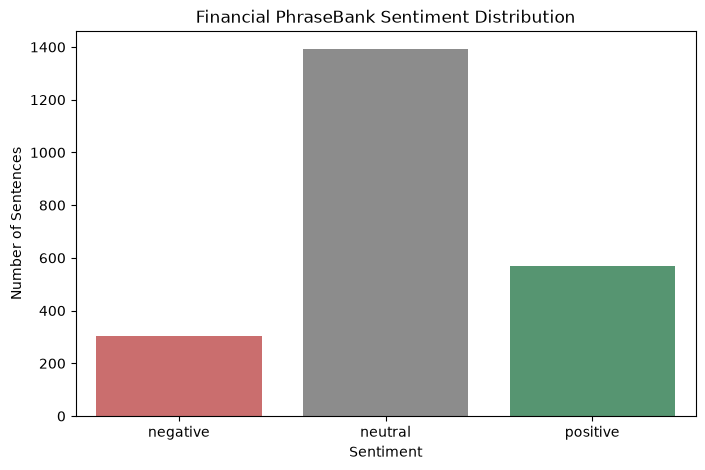

In [4]:
# Count the number of examples in each sentiment category
sentiment_order = ["negative", "neutral", "positive"]
sentiment_counts = (
    phrasebank_df["sentiment"]
    .value_counts()
    .reindex(sentiment_order)
)

print(sentiment_counts)

# Visualize the sentiment distribution
plt.figure(figsize=(8, 5))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    hue=sentiment_counts.index,
    palette=["#d95f5f", "#8c8c8c", "#4c9f70"],
    legend=False
)

plt.title("Financial PhraseBank Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Sentences")
plt.show()

**Observation:** The dataset is imbalanced, with neutral sentences representing the majority of the observations. Negative sentences are the least common. Because of this imbalance, we should evaluate our sentiment classifier using precision, recall, and F1-score in addition to accuracy. We may also use stratified data splitting to preserve the sentiment distribution across training and testing sets.

### 2.2 Data Quality Checks

Before preprocessing the financial text, we check for missing values, duplicate sentences, and empty text entries. These checks help us avoid using incomplete or repeated observations in later analysis.

In [5]:
# Check the dataset for common data-quality issues
missing_values = phrasebank_df.isnull().sum()
duplicate_sentences = phrasebank_df["sentence"].duplicated().sum()
empty_sentences = phrasebank_df["sentence"].str.strip().eq("").sum()

print("Missing values:")
print(missing_values)
print(f"\nDuplicate sentences: {duplicate_sentences}")
print(f"Empty sentences: {empty_sentences}")

Missing values:
sentence     0
label        0
sentiment    0
dtype: int64

Duplicate sentences: 5
Empty sentences: 0


**Observation:** We found no missing values or empty sentences. We identified five duplicate sentences, which we remove to prevent repeated observations from influencing later analysis.

In [6]:
# Remove duplicate sentences while preserving the original DataFrame
phrasebank_clean = (
    phrasebank_df
    .drop_duplicates(subset="sentence")
    .reset_index(drop=True)
    .copy()
)

removed_rows = len(phrasebank_df) - len(phrasebank_clean)

print(f"Rows before cleaning: {len(phrasebank_df)}")
print(f"Duplicate rows removed: {removed_rows}")
print(f"Rows after cleaning: {len(phrasebank_clean)}")

Rows before cleaning: 2264
Duplicate rows removed: 5
Rows after cleaning: 2259


### 2.3 Yahoo Finance Market Data

Our system uses Yahoo Finance as a dynamic tool for retrieving current and historical stock-market data. We use Apple (`AAPL`) as an initial example, but the completed agent will accept any valid stock ticker entered by the user.

In [7]:
# Retrieve one year of historical market data for an example stock
example_ticker = "AAPL"
stock = yf.Ticker(example_ticker)

market_data = stock.history(
    period="1y",
    interval="1d",
    auto_adjust=False
)

if market_data.empty:
    raise ValueError(f"No market data was returned for {example_ticker}.")

print(f"Ticker: {example_ticker}")
print(f"Number of trading days: {len(market_data)}")
display(market_data.tail())

Ticker: AAPL
Number of trading days: 251


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2026-09-28 00:00:00-04:00,340.369995,342.989990,338.040009,338.399994,338.399994,32820800,0.0,0.0
2026-09-29 00:00:00-04:00,336.970001,337.089996,328.700012,329.399994,329.399994,38478000,0.0,0.0
2026-09-30 00:00:00-04:00,330.799988,339.500000,330.140015,333.019989,333.019989,49988600,0.0,0.0
2026-10-01 00:00:00-04:00,330.000000,332.480011,325.809998,330.320007,330.320007,36306300,0.0,0.0
2026-10-02 00:00:00-04:00,333.260010,334.540009,330.609985,333.690002,333.690002,33245500,0.0,0.0


### 2.4 Initial Market Overview

We calculate daily returns and moving averages to create basic market indicators for the Market Analysis Agent. These indicators help the agent identify recent price direction, short-term momentum, and potential market risk.

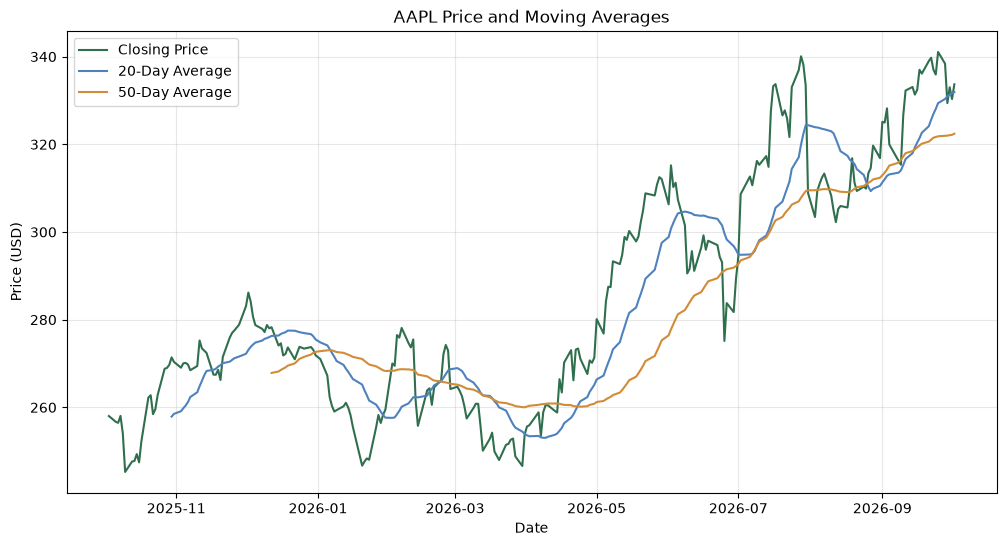

In [8]:
# Create basic market indicators
market_data["Daily Return"] = market_data["Close"].pct_change()
market_data["20-Day Average"] = market_data["Close"].rolling(window=20).mean()
market_data["50-Day Average"] = market_data["Close"].rolling(window=50).mean()

# Plot the closing price and moving averages
plt.figure(figsize=(12, 6))
plt.plot(
    market_data.index,
    market_data["Close"],
    label="Closing Price",
    color="#2f6f4e"
)
plt.plot(
    market_data.index,
    market_data["20-Day Average"],
    label="20-Day Average",
    color="#4f81bd"
)
plt.plot(
    market_data.index,
    market_data["50-Day Average"],
    label="50-Day Average",
    color="#d28b36"
)

plt.title(f"{example_ticker} Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Multi-Agent System Design

We designed our Investment Research Agent as a coordinated system of specialized agents. A user provides a stock ticker, and the coordinator creates a research plan, selects the appropriate tools, routes information to specialist agents, and combines their findings into a final research brief.

Our system includes the following agents:

1. **Coordinator and Planning Agent:** Creates the research plan, routes tasks, and combines the results.
2. **News Analysis Agent:** Processes financial news, classifies sentiment, extracts important information, and summarizes recent developments.
3. **Market Analysis Agent:** Evaluates price movements, trading volume, daily returns, and moving averages.
4. **Earnings Analysis Agent:** Reviews company financials and earnings-related information.
5. **Evaluator Agent:** Scores the completed analysis and provides feedback for revision.
6. **Memory Component:** Stores brief notes from previous runs so the system can improve future analyses.

Together, these components demonstrate planning, dynamic tool use, self-reflection, learning across runs, prompt chaining, routing, and evaluator–optimizer workflows.

### 3.1 Coordinator and Planning Agent

The Coordinator Agent receives a stock ticker and creates a structured research plan. It determines which specialist agents and tools should be used before any analysis begins. This makes the workflow transparent and allows the system to adapt its plan to the requested research areas.

In [9]:
def create_research_plan(
    ticker,
    include_news=True,
    include_market=True,
    include_earnings=True
):
    """Create a structured research plan for a stock ticker."""
    ticker = ticker.strip().upper()

    if not ticker:
        raise ValueError("A valid stock ticker is required.")

    plan = {
        "ticker": ticker,
        "objective": f"Create an investment research brief for {ticker}.",
        "tasks": []
    }

    if include_market:
        plan["tasks"].append(
            {
                "step": len(plan["tasks"]) + 1,
                "agent": "Market Analysis Agent",
                "tool": "Yahoo Finance",
                "task": "Analyze prices, returns, volume, and moving averages."
            }
        )

    if include_news:
        plan["tasks"].append(
            {
                "step": len(plan["tasks"]) + 1,
                "agent": "News Analysis Agent",
                "tool": "Financial news and sentiment model",
                "task": "Process news, classify sentiment, and summarize key events."
            }
        )

    if include_earnings:
        plan["tasks"].append(
            {
                "step": len(plan["tasks"]) + 1,
                "agent": "Earnings Analysis Agent",
                "tool": "Yahoo Finance financial statements",
                "task": "Review earnings and company financial performance."
            }
        )

    plan["tasks"].append(
        {
            "step": len(plan["tasks"]) + 1,
            "agent": "Evaluator Agent",
            "tool": "Quality-scoring rubric",
            "task": "Evaluate and refine the completed research brief."
        }
    )

    return plan


research_plan = create_research_plan("AAPL")
research_plan

{'ticker': 'AAPL',
 'objective': 'Create an investment research brief for AAPL.',
 'tasks': [{'step': 1,
   'agent': 'Market Analysis Agent',
   'tool': 'Yahoo Finance',
   'task': 'Analyze prices, returns, volume, and moving averages.'},
  {'step': 2,
   'agent': 'News Analysis Agent',
   'tool': 'Financial news and sentiment model',
   'task': 'Process news, classify sentiment, and summarize key events.'},
  {'step': 3,
   'agent': 'Earnings Analysis Agent',
   'tool': 'Yahoo Finance financial statements',
   'task': 'Review earnings and company financial performance.'},
  {'step': 4,
   'agent': 'Evaluator Agent',
   'tool': 'Quality-scoring rubric',
   'task': 'Evaluate and refine the completed research brief.'}]}

### 3.2 Routing Workflow

The routing workflow examines the content of a research request and directs it to the most appropriate specialist. Market-related requests go to the Market Analysis Agent, news-related requests go to the News Analysis Agent, and financial-performance requests go to the Earnings Analysis Agent. Unclear requests return to the Coordinator Agent for further planning.

In [10]:
def route_research_request(request):
    """Route a research request to the appropriate specialist agent."""
    request_text = request.lower()

    routing_keywords = {
        "Market Analysis Agent": [
            "price", "volume", "return", "volatility",
            "moving average", "market"
        ],
        "News Analysis Agent": [
            "news", "headline", "sentiment", "announcement",
            "event", "article"
        ],
        "Earnings Analysis Agent": [
            "earnings", "revenue", "profit", "financial",
            "income", "balance sheet"
        ]
    }

    scores = {
        agent: sum(
            keyword in request_text
            for keyword in keywords
        )
        for agent, keywords in routing_keywords.items()
    }

    selected_agent = max(scores, key=scores.get)

    if scores[selected_agent] == 0:
        selected_agent = "Coordinator Agent"

    return {
        "request": request,
        "selected_agent": selected_agent,
        "routing_scores": scores
    }


sample_requests = [
    "Analyze recent price changes and trading volume.",
    "Summarize the latest company news and sentiment.",
    "Review revenue, profit, and quarterly earnings."
]

routing_results = [
    route_research_request(request)
    for request in sample_requests
]

routing_results

[{'request': 'Analyze recent price changes and trading volume.',
  'selected_agent': 'Market Analysis Agent',
  'routing_scores': {'Market Analysis Agent': 2,
   'News Analysis Agent': 0,
   'Earnings Analysis Agent': 0}},
 {'request': 'Summarize the latest company news and sentiment.',
  'selected_agent': 'News Analysis Agent',
  'routing_scores': {'Market Analysis Agent': 0,
   'News Analysis Agent': 2,
   'Earnings Analysis Agent': 0}},
 {'request': 'Review revenue, profit, and quarterly earnings.',
  'selected_agent': 'Earnings Analysis Agent',
  'routing_scores': {'Market Analysis Agent': 0,
   'News Analysis Agent': 0,
   'Earnings Analysis Agent': 3}}]

### 3.3 Market Analysis Agent

The Market Analysis Agent dynamically retrieves historical stock data from Yahoo Finance. It calculates price change, annualized volatility, average trading volume, and moving averages. It then uses these indicators to identify the stock’s current market trend.

In [11]:
def market_analysis_agent(ticker, period="1y"):
    """Retrieve market data and calculate key market indicators."""
    ticker = ticker.strip().upper()
    stock_data = yf.Ticker(ticker).history(
        period=period,
        interval="1d",
        auto_adjust=False
    )

    if stock_data.empty:
        raise ValueError(f"No market data was returned for {ticker}.")

    closing_prices = stock_data["Close"].dropna()
    daily_returns = closing_prices.pct_change().dropna()

    first_price = closing_prices.iloc[0]
    latest_price = closing_prices.iloc[-1]
    period_return = ((latest_price / first_price) - 1) * 100
    annualized_volatility = daily_returns.std() * np.sqrt(252) * 100
    average_volume = stock_data["Volume"].mean()

    average_20 = closing_prices.rolling(window=20).mean().iloc[-1]
    average_50 = closing_prices.rolling(window=50).mean().iloc[-1]

    if latest_price > average_20 > average_50:
        trend = "Bullish"
    elif latest_price < average_20 < average_50:
        trend = "Bearish"
    else:
        trend = "Mixed"

    return {
        "ticker": ticker,
        "period": period,
        "latest_price": round(float(latest_price), 2),
        "period_return_percent": round(float(period_return), 2),
        "annualized_volatility_percent": round(
            float(annualized_volatility),
            2
        ),
        "average_daily_volume": round(float(average_volume)),
        "20_day_average": round(float(average_20), 2),
        "50_day_average": round(float(average_50), 2),
        "trend": trend,
        "tool_used": "Yahoo Finance"
    }


market_analysis = market_analysis_agent("AAPL")
market_analysis

{'ticker': 'AAPL',
 'period': '1y',
 'latest_price': 333.69,
 'period_return_percent': 29.33,
 'annualized_volatility_percent': 24.75,
 'average_daily_volume': 48195212,
 '20_day_average': 331.89,
 '50_day_average': 322.42,
 'trend': 'Bullish',
 'tool_used': 'Yahoo Finance'}

### 3.4 Earnings Analysis Agent

The Earnings Analysis Agent retrieves the company’s quarterly income statement from Yahoo Finance. It extracts important financial measures, including revenue, net income, and earnings per share. When prior-quarter data is available, it also calculates revenue growth.

In [12]:
def earnings_analysis_agent(ticker):
    """Retrieve and analyze recent quarterly earnings data."""
    ticker = ticker.strip().upper()
    stock = yf.Ticker(ticker)
    income_statement = stock.quarterly_income_stmt

    if income_statement.empty:
        raise ValueError(
            f"No quarterly income statement was returned for {ticker}."
        )

    latest_quarter = income_statement.columns[0]
    previous_quarter = (
        income_statement.columns[1]
        if len(income_statement.columns) > 1
        else None
    )

    def get_financial_value(row_name, quarter):
        if row_name in income_statement.index and quarter is not None:
            value = income_statement.loc[row_name, quarter]
            if pd.notna(value):
                return float(value)
        return None

    latest_revenue = get_financial_value(
        "Total Revenue",
        latest_quarter
    )
    previous_revenue = get_financial_value(
        "Total Revenue",
        previous_quarter
    )
    net_income = get_financial_value(
        "Net Income",
        latest_quarter
    )
    diluted_eps = get_financial_value(
        "Diluted EPS",
        latest_quarter
    )

    revenue_growth = None
    if latest_revenue is not None and previous_revenue:
        revenue_growth = (
            (latest_revenue / previous_revenue) - 1
        ) * 100

    return {
        "ticker": ticker,
        "latest_quarter": str(latest_quarter.date()),
        "revenue": latest_revenue,
        "net_income": net_income,
        "diluted_eps": diluted_eps,
        "quarterly_revenue_growth_percent": (
            round(revenue_growth, 2)
            if revenue_growth is not None
            else None
        ),
        "tool_used": "Yahoo Finance quarterly income statement"
    }


earnings_analysis = earnings_analysis_agent("AAPL")
earnings_analysis

{'ticker': 'AAPL',
 'latest_quarter': '2026-06-30',
 'revenue': 109417000000.0,
 'net_income': 29789000000.0,
 'diluted_eps': 2.02,
 'quarterly_revenue_growth_percent': -1.59,
 'tool_used': 'Yahoo Finance quarterly income statement'}

### 3.5 Financial Sentiment Model

We train a financial sentiment classifier using the cleaned Financial PhraseBank dataset. We use TF-IDF to convert financial text into numerical features and logistic regression to classify each sentence as negative, neutral, or positive. We use stratified splitting and balanced class weights because the dataset contains more neutral examples than positive or negative examples.

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Create stratified training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    phrasebank_clean["sentence"],
    phrasebank_clean["sentiment"],
    test_size=0.20,
    random_state=42,
    stratify=phrasebank_clean["sentiment"]
)

# Build and train the financial sentiment model
sentiment_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_features=10000
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

sentiment_model.fit(x_train, y_train)
sentiment_predictions = sentiment_model.predict(x_test)

print(
    f"Accuracy: "
    f"{accuracy_score(y_test, sentiment_predictions):.3f}"
)
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        sentiment_predictions,
        zero_division=0
    )
)

Accuracy: 0.896

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.85      0.82        61
     neutral       0.95      0.93      0.94       277
    positive       0.83      0.83      0.83       114

    accuracy                           0.90       452
   macro avg       0.86      0.87      0.86       452
weighted avg       0.90      0.90      0.90       452



### 3.6 News Prompt-Chaining Workflow

The News Analysis Agent follows the required prompt-chaining sequence: ingest news, preprocess the text, classify sentiment, extract important information, and summarize the results. Each stage passes its output to the next stage.

In [15]:
def ingest_financial_news(ticker, max_articles=10):
    """Retrieve and organize recent financial news from Yahoo Finance."""
    ticker = ticker.strip().upper()

    # Search Yahoo Finance directly for recent ticker news
    search_results = yf.Search(
        ticker,
        news_count=max_articles
    )

    raw_news = search_results.news or []
    articles = []

    for item in raw_news:
        title = item.get("title")
        publisher = item.get("publisher")
        link = item.get("link")
        summary = (
            item.get("summary")
            or item.get("description")
            or ""
        )

        if title:
            articles.append(
                {
                    "ticker": ticker,
                    "title": title,
                    "summary": summary,
                    "publisher": publisher,
                    "link": link
                }
            )

    return pd.DataFrame(articles)


news_df = ingest_financial_news("AAPL")

print(f"News articles retrieved: {len(news_df)}")
display(news_df.head())

News articles retrieved: 10


,ticker,title,summary,publisher,link
0,AAPL,This Stock Posted the Best Performance in the “Magnificent Seven” in September. (Hint: It’s Not Nvidia.),,Motley Fool,https://finance.yahoo.com/markets/stocks/articles/stock-posted-best-performance-magnificent-133001553.html
1,AAPL,"Mag 7 Voices: Huang Defends AI Spending, Pichai Ramps Up Gemini, Nadella Calls Copilot A ‘New OS For Work’ This Week",,Stocktwits,https://finance.yahoo.com/technology/ai/articles/mag-7-voices-huang-defends-020135909.html
2,AAPL,Apple Says Some AT&T iPhone 18 Pro Max Users Must Replace Phones After Service-Loss Bug,,MT Newswires,https://finance.yahoo.com/technology/articles/apple-says-t-iphone-18-230333132.html
3,AAPL,Apple Tightens macOS Full Disk Access,,MT Newswires,https://finance.yahoo.com/technology/ai/articles/apple-tightens-macos-full-disk-220615201.html
4,AAPL,Apple iPhone 18 Pro Max AT&T Glitch Requires Device Replacements,,Bloomberg,https://finance.yahoo.com/technology/articles/apple-iphone-18-pro-max-220128822.html


#### News Preprocessing and Sentiment Classification

The News Analysis Agent cleans each article’s text and combines the title with the available summary. It then passes the processed text to our trained financial sentiment model, producing a sentiment label and confidence score for each article.

In [16]:
def preprocess_news(news_data):
    """Clean and combine news titles and summaries."""
    processed_news = news_data.copy()

    processed_news["text"] = (
        processed_news["title"].fillna("")
        + ". "
        + processed_news["summary"].fillna("")
    )

    processed_news["text"] = (
        processed_news["text"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return processed_news


def classify_news_sentiment(news_data, model):
    """Predict sentiment and confidence for each news article."""
    classified_news = news_data.copy()

    classified_news["sentiment"] = model.predict(
        classified_news["text"]
    )

    probabilities = model.predict_proba(
        classified_news["text"]
    )

    classified_news["confidence"] = (
        probabilities.max(axis=1).round(3)
    )

    return classified_news


processed_news_df = preprocess_news(news_df)

classified_news_df = classify_news_sentiment(
    processed_news_df,
    sentiment_model
)

display(
    classified_news_df[
        ["title", "publisher", "sentiment", "confidence"]
    ]
)

,title,publisher,sentiment,confidence
0,This Stock Posted the Best Performance in the “Magnificent Seven” in September. (Hint: It’s Not Nvidia.),Motley Fool,neutral,0.459
1,"Mag 7 Voices: Huang Defends AI Spending, Pichai Ramps Up Gemini, Nadella Calls Copilot A ‘New OS For Work’ This Week",Stocktwits,positive,0.468
2,Apple Says Some AT&T iPhone 18 Pro Max Users Must Replace Phones After Service-Loss Bug,MT Newswires,neutral,0.612
3,Apple Tightens macOS Full Disk Access,MT Newswires,neutral,0.693
4,Apple iPhone 18 Pro Max AT&T Glitch Requires Device Replacements,Bloomberg,neutral,0.624
5,Apple (AAPL) Exceeds Market Returns: Some Facts to Consider,Zacks,positive,0.420
6,"Microsoft Entered the Smart Home Through Your Washing Machine, Not Your Phone",Forkast News,neutral,0.792
7,Morgan Stanley Has Strong Verdict for Apple Stock Investors,GuruFocus.com,positive,0.588
8,"Buy, Hold, or Fade Tesla Stock After Its Q3 Delivery Beat?",Zacks,neutral,0.517
9,Apple Stocks Rises Although AI Agents Threaten App-Store Gatekeeping,GuruFocus.com,neutral,0.586


#### News Relevance Filtering

Yahoo Finance search results may occasionally contain stories about other companies. The agent therefore filters the retrieved articles for company-specific terms before producing its final news analysis.

In [17]:
def filter_relevant_news(news_data, company_terms):
    """Keep articles containing at least one company-specific term."""
    search_pattern = "|".join(company_terms)

    relevant_mask = news_data["text"].str.contains(
        search_pattern,
        case=False,
        regex=True,
        na=False
    )

    return news_data.loc[relevant_mask].reset_index(drop=True)


apple_terms = [
    r"\bAAPL\b",
    r"\bApple\b",
    r"\biPhone\b",
    r"\bmacOS\b",
    r"\bApp Store\b"
]

relevant_news_df = filter_relevant_news(
    classified_news_df,
    apple_terms
)

print(
    f"Relevant Apple articles retained: "
    f"{len(relevant_news_df)} of {len(classified_news_df)}"
)

display(
    relevant_news_df[
        ["title", "publisher", "sentiment", "confidence"]
    ]
)

Relevant Apple articles retained: 6 of 10


,title,publisher,sentiment,confidence
0,Apple Says Some AT&T iPhone 18 Pro Max Users Must Replace Phones After Service-Loss Bug,MT Newswires,neutral,0.612
1,Apple Tightens macOS Full Disk Access,MT Newswires,neutral,0.693
2,Apple iPhone 18 Pro Max AT&T Glitch Requires Device Replacements,Bloomberg,neutral,0.624
3,Apple (AAPL) Exceeds Market Returns: Some Facts to Consider,Zacks,positive,0.420
4,Morgan Stanley Has Strong Verdict for Apple Stock Investors,GuruFocus.com,positive,0.588
5,Apple Stocks Rises Although AI Agents Threaten App-Store Gatekeeping,GuruFocus.com,neutral,0.586


#### Information Extraction and News Summary

The agent aggregates the article-level predictions to identify the dominant sentiment, sentiment distribution, and most relevant headlines. This converts the individual classifications into a concise news summary that can be passed to the Coordinator Agent.

In [19]:
def summarize_news_analysis(ticker, news_data):
    """Create a structured summary of relevant financial news."""
    if news_data.empty:
        return {
            "ticker": ticker,
            "articles_analyzed": 0,
            "dominant_sentiment": "Unavailable",
            "sentiment_counts": {},
            "average_confidence": None,
            "key_headlines": [],
            "tool_used": (
                "Yahoo Finance Search and trained "
                "Financial PhraseBank classifier"
            )
        }

    sentiment_counts = (
        news_data["sentiment"]
        .value_counts()
        .to_dict()
    )

    dominant_sentiment = (
        news_data["sentiment"]
        .value_counts()
        .idxmax()
    )

    key_articles = (
        news_data
        .sort_values("confidence", ascending=False)
        .head(3)
    )

    key_headlines = [
        {
            "title": row["title"],
            "sentiment": row["sentiment"],
            "confidence": float(row["confidence"]),
            "publisher": row["publisher"]
        }
        for _, row in key_articles.iterrows()
    ]

    return {
        "ticker": ticker,
        "articles_analyzed": len(news_data),
        "dominant_sentiment": dominant_sentiment,
        "sentiment_counts": sentiment_counts,
        "average_confidence": round(
            float(news_data["confidence"].mean()),
            3
        ),
        "key_headlines": key_headlines,
        "tool_used": (
            "Yahoo Finance Search and trained "
            "Financial PhraseBank classifier"
        )
    }


news_analysis = summarize_news_analysis(
    "AAPL",
    relevant_news_df
)

news_analysis

{'ticker': 'AAPL',
 'articles_analyzed': 6,
 'dominant_sentiment': 'neutral',
 'sentiment_counts': {'neutral': 4, 'positive': 2},
 'average_confidence': 0.587,
 'key_headlines': [{'title': 'Apple Tightens macOS Full Disk Access',
   'sentiment': 'neutral',
   'confidence': 0.693,
   'publisher': 'MT Newswires'},
  {'title': 'Apple iPhone 18 Pro Max AT&T Glitch Requires Device Replacements',
   'sentiment': 'neutral',
   'confidence': 0.624,
   'publisher': 'Bloomberg'},
  {'title': 'Apple Says Some AT&T iPhone 18 Pro Max Users Must Replace Phones After Service-Loss Bug',
   'sentiment': 'neutral',
   'confidence': 0.612,
   'publisher': 'MT Newswires'}],
 'tool_used': 'Yahoo Finance Search and trained Financial PhraseBank classifier'}

### 3.7 Complete News Analysis Agent

We combine the news-ingestion, preprocessing, relevance-filtering, sentiment-classification, and summarization stages into one reusable News Analysis Agent. This completes the prompt-chaining workflow and allows the Coordinator Agent to call the entire sequence with a single function.

In [20]:
def news_analysis_agent(
    ticker,
    company_terms,
    sentiment_model,
    max_articles=10
):
    """Run the complete financial-news analysis workflow."""
    ticker = ticker.strip().upper()

    # Step 1: Ingest recent news
    raw_news = ingest_financial_news(
        ticker,
        max_articles=max_articles
    )

    if raw_news.empty:
        return summarize_news_analysis(
            ticker,
            pd.DataFrame()
        )

    # Step 2: Preprocess the text
    processed_news = preprocess_news(raw_news)

    # Step 3: Classify financial sentiment
    classified_news = classify_news_sentiment(
        processed_news,
        sentiment_model
    )

    # Step 4: Remove unrelated search results
    relevant_news = filter_relevant_news(
        classified_news,
        company_terms
    )

    # Step 5: Produce the agent summary
    return summarize_news_analysis(
        ticker,
        relevant_news
    )


apple_terms = [
    r"\bAAPL\b",
    r"\bApple\b",
    r"\biPhone\b",
    r"\bmacOS\b",
    r"\bApp Store\b"
]

complete_news_analysis = news_analysis_agent(
    ticker="AAPL",
    company_terms=apple_terms,
    sentiment_model=sentiment_model,
    max_articles=10
)

complete_news_analysis

{'ticker': 'AAPL',
 'articles_analyzed': 6,
 'dominant_sentiment': 'neutral',
 'sentiment_counts': {'neutral': 4, 'positive': 2},
 'average_confidence': 0.587,
 'key_headlines': [{'title': 'Apple Tightens macOS Full Disk Access',
   'sentiment': 'neutral',
   'confidence': 0.693,
   'publisher': 'MT Newswires'},
  {'title': 'Apple iPhone 18 Pro Max AT&T Glitch Requires Device Replacements',
   'sentiment': 'neutral',
   'confidence': 0.624,
   'publisher': 'Bloomberg'},
  {'title': 'Apple Says Some AT&T iPhone 18 Pro Max Users Must Replace Phones After Service-Loss Bug',
   'sentiment': 'neutral',
   'confidence': 0.612,
   'publisher': 'MT Newswires'}],
 'tool_used': 'Yahoo Finance Search and trained Financial PhraseBank classifier'}

## 4. Coordinator Integration

The Coordinator Agent executes the research plan and calls each specialist agent. It gathers market, earnings, and news results into one structured output. Each specialist operates independently, allowing the coordinator to preserve partial results if one external data source is temporarily unavailable.

In [21]:
def coordinator_agent(
    ticker,
    company_terms,
    sentiment_model
):
    """Coordinate the specialist agents for one stock ticker."""
    ticker = ticker.strip().upper()

    research_plan = create_research_plan(ticker)
    specialist_results = {}
    agent_errors = {}

    # Call the Market Analysis Agent
    try:
        specialist_results["market_analysis"] = (
            market_analysis_agent(ticker)
        )
    except Exception as error:
        specialist_results["market_analysis"] = None
        agent_errors["market_analysis"] = str(error)

    # Call the Earnings Analysis Agent
    try:
        specialist_results["earnings_analysis"] = (
            earnings_analysis_agent(ticker)
        )
    except Exception as error:
        specialist_results["earnings_analysis"] = None
        agent_errors["earnings_analysis"] = str(error)

    # Call the News Analysis Agent
    try:
        specialist_results["news_analysis"] = (
            news_analysis_agent(
                ticker=ticker,
                company_terms=company_terms,
                sentiment_model=sentiment_model,
                max_articles=10
            )
        )
    except Exception as error:
        specialist_results["news_analysis"] = None
        agent_errors["news_analysis"] = str(error)

    completed_agents = [
        agent_name
        for agent_name, result in specialist_results.items()
        if result is not None
    ]

    return {
        "ticker": ticker,
        "research_plan": research_plan,
        "specialist_results": specialist_results,
        "completed_agents": completed_agents,
        "agent_errors": agent_errors,
        "status": (
            "Complete"
            if len(completed_agents) == 3
            else "Partially Complete"
        )
    }


coordinated_analysis = coordinator_agent(
    ticker="AAPL",
    company_terms=apple_terms,
    sentiment_model=sentiment_model
)

coordinated_analysis

{'ticker': 'AAPL',
 'research_plan': {'ticker': 'AAPL',
  'objective': 'Create an investment research brief for AAPL.',
  'tasks': [{'step': 1,
    'agent': 'Market Analysis Agent',
    'tool': 'Yahoo Finance',
    'task': 'Analyze prices, returns, volume, and moving averages.'},
   {'step': 2,
    'agent': 'News Analysis Agent',
    'tool': 'Financial news and sentiment model',
    'task': 'Process news, classify sentiment, and summarize key events.'},
   {'step': 3,
    'agent': 'Earnings Analysis Agent',
    'tool': 'Yahoo Finance financial statements',
    'task': 'Review earnings and company financial performance.'},
   {'step': 4,
    'agent': 'Evaluator Agent',
    'tool': 'Quality-scoring rubric',
    'task': 'Evaluate and refine the completed research brief.'}]},
 'specialist_results': {'market_analysis': {'ticker': 'AAPL',
   'period': '1y',
   'latest_price': 333.69,
   'period_return_percent': 29.33,
   'annualized_volatility_percent': 24.75,
   'average_daily_volume': 4819

## 5. Investment Research Brief Generator

The research-brief generator converts the structured specialist outputs into a readable report. It summarizes market performance, earnings, news sentiment, and important risk considerations. The report is intended for research and educational purposes rather than personalized financial advice.

In [22]:
def generate_research_brief(coordinator_output):
    """Convert coordinated agent results into a readable research brief."""
    ticker = coordinator_output["ticker"]
    results = coordinator_output["specialist_results"]

    market = results.get("market_analysis")
    earnings = results.get("earnings_analysis")
    news = results.get("news_analysis")

    brief = {
        "title": f"Investment Research Brief: {ticker}",
        "system_status": coordinator_output["status"],
        "executive_summary": "",
        "market_overview": "",
        "earnings_overview": "",
        "news_overview": "",
        "risk_considerations": [],
        "disclaimer": (
            "This report is generated for educational and research "
            "purposes only and is not personalized financial advice."
        )
    }

    summary_points = []

    if market:
        brief["market_overview"] = (
            f"{ticker} has a latest closing price of "
            f"${market['latest_price']:,.2f}. The stock returned "
            f"{market['period_return_percent']:.2f}% over the selected "
            f"{market['period']} period, with annualized volatility of "
            f"{market['annualized_volatility_percent']:.2f}%. Its current "
            f"technical trend is classified as {market['trend'].lower()}."
        )

        summary_points.append(
            f"a {market['trend'].lower()} market trend"
        )

        if market["annualized_volatility_percent"] >= 30:
            brief["risk_considerations"].append(
                "The stock has relatively high historical volatility."
            )

    if earnings:
        revenue_billions = earnings["revenue"] / 1_000_000_000
        income_billions = earnings["net_income"] / 1_000_000_000
        revenue_growth = earnings[
            "quarterly_revenue_growth_percent"
        ]

        brief["earnings_overview"] = (
            f"For the quarter ending {earnings['latest_quarter']}, "
            f"{ticker} reported revenue of "
            f"${revenue_billions:,.2f} billion, net income of "
            f"${income_billions:,.2f} billion, and diluted EPS of "
            f"${earnings['diluted_eps']:.2f}. Quarterly revenue growth "
            f"was {revenue_growth:.2f}%."
        )

        growth_direction = (
            "positive"
            if revenue_growth >= 0
            else "negative"
        )

        summary_points.append(
            f"{growth_direction} quarterly revenue growth"
        )

        if revenue_growth < 0:
            brief["risk_considerations"].append(
                "Revenue declined compared with the previous quarter."
            )

    if news:
        brief["news_overview"] = (
            f"The News Analysis Agent examined "
            f"{news['articles_analyzed']} relevant articles. The dominant "
            f"sentiment was {news['dominant_sentiment']}, with an average "
            f"classification confidence of "
            f"{news['average_confidence']:.1%}."
        )

        summary_points.append(
            f"{news['dominant_sentiment']} recent news sentiment"
        )

        if news["average_confidence"] < 0.60:
            brief["risk_considerations"].append(
                "News-sentiment confidence is moderate, so individual "
                "article classifications should be interpreted cautiously."
            )

    if summary_points:
        brief["executive_summary"] = (
            f"The coordinated analysis of {ticker} identified "
            + ", ".join(summary_points)
            + ". These indicators should be considered together rather "
            + "than treated as an investment recommendation."
        )
    else:
        brief["executive_summary"] = (
            "The system could not retrieve enough information to create "
            "a complete research summary."
        )

    if not brief["risk_considerations"]:
        brief["risk_considerations"].append(
            "Historical results and current sentiment do not guarantee "
            "future investment performance."
        )

    return brief


research_brief = generate_research_brief(
    coordinated_analysis
)

research_brief

{'title': 'Investment Research Brief: AAPL',
 'system_status': 'Complete',
 'executive_summary': 'The coordinated analysis of AAPL identified a bullish market trend, negative quarterly revenue growth, neutral recent news sentiment. These indicators should be considered together rather than treated as an investment recommendation.',
 'market_overview': 'AAPL has a latest closing price of $333.69. The stock returned 29.33% over the selected 1y period, with annualized volatility of 24.75%. Its current technical trend is classified as bullish.',
 'earnings_overview': 'For the quarter ending 2026-06-30, AAPL reported revenue of $109.42 billion, net income of $29.79 billion, and diluted EPS of $2.02. Quarterly revenue growth was -1.59%.',
 'news_overview': 'The News Analysis Agent examined 6 relevant articles. The dominant sentiment was neutral, with an average classification confidence of 58.7%.',
 'risk_considerations': ['Revenue declined compared with the previous quarter.',
  'News-senti

## 6. Evaluator Agent

The Evaluator Agent reviews the completed research brief using a transparent quality-scoring rubric. It checks whether the report contains an executive summary, market analysis, earnings analysis, news analysis, risk considerations, and a responsible-use disclaimer. It then provides feedback that can be used by the optimizer.

In [23]:
def evaluator_agent(research_brief):
    """Evaluate a research brief using a quality-scoring rubric."""
    rubric = {
        "executive_summary": 20,
        "market_overview": 20,
        "earnings_overview": 20,
        "news_overview": 15,
        "risk_considerations": 15,
        "disclaimer": 10
    }

    scores = {}
    feedback = []

    for criterion, available_points in rubric.items():
        content = research_brief.get(criterion)

        if isinstance(content, list):
            criterion_complete = len(content) > 0
        else:
            criterion_complete = bool(
                content and str(content).strip()
            )

        if criterion_complete:
            scores[criterion] = available_points
        else:
            scores[criterion] = 0
            readable_name = criterion.replace("_", " ")
            feedback.append(
                f"Add or improve the {readable_name} section."
            )

    total_score = sum(scores.values())
    quality_threshold = 80
    passed = total_score >= quality_threshold

    if passed and not feedback:
        feedback.append(
            "The report contains all required components."
        )

    return {
        "total_score": total_score,
        "maximum_score": 100,
        "quality_threshold": quality_threshold,
        "passed": passed,
        "criterion_scores": scores,
        "feedback": feedback
    }


evaluation = evaluator_agent(research_brief)

evaluation

{'total_score': 100,
 'maximum_score': 100,
 'quality_threshold': 80,
 'passed': True,
 'criterion_scores': {'executive_summary': 20,
  'market_overview': 20,
  'earnings_overview': 20,
  'news_overview': 15,
  'risk_considerations': 15,
  'disclaimer': 10},
 'feedback': ['The report contains all required components.']}

## 7. Evaluator-Optimizer Workflow

The evaluator–optimizer workflow repeatedly reviews and improves the research brief until it reaches the required quality threshold or the maximum number of revision attempts is reached. If the report already passes, the system avoids unnecessary revisions. This demonstrates self-reflection and controlled iterative improvement.

In [24]:
def optimize_research_brief(
    research_brief,
    evaluation
):
    """Improve missing report components using evaluator feedback."""
    optimized_brief = research_brief.copy()

    default_content = {
        "executive_summary": (
            "The available agent outputs were reviewed, but some "
            "information was unavailable."
        ),
        "market_overview": (
            "Market information was unavailable during this system run."
        ),
        "earnings_overview": (
            "Earnings information was unavailable during this system run."
        ),
        "news_overview": (
            "Relevant news information was unavailable during this run."
        ),
        "risk_considerations": [
            "Missing or delayed data may reduce the completeness of this report."
        ],
        "disclaimer": (
            "This report is generated for educational and research "
            "purposes only and is not personalized financial advice."
        )
    }

    for criterion, score in evaluation["criterion_scores"].items():
        if score == 0:
            optimized_brief[criterion] = default_content[criterion]

    return optimized_brief


def evaluator_optimizer_workflow(
    coordinator_output,
    max_iterations=3
):
    """Generate, evaluate, and improve a research brief."""
    current_brief = generate_research_brief(
        coordinator_output
    )

    iteration_history = []

    for iteration in range(1, max_iterations + 1):
        current_evaluation = evaluator_agent(
            current_brief
        )

        iteration_history.append(
            {
                "iteration": iteration,
                "score": current_evaluation["total_score"],
                "passed": current_evaluation["passed"],
                "feedback": current_evaluation["feedback"]
            }
        )

        if current_evaluation["passed"]:
            break

        current_brief = optimize_research_brief(
            current_brief,
            current_evaluation
        )

    return {
        "final_brief": current_brief,
        "final_evaluation": current_evaluation,
        "iterations_completed": len(iteration_history),
        "iteration_history": iteration_history
    }


optimized_result = evaluator_optimizer_workflow(
    coordinated_analysis
)

optimized_result

{'final_brief': {'title': 'Investment Research Brief: AAPL',
  'system_status': 'Complete',
  'executive_summary': 'The coordinated analysis of AAPL identified a bullish market trend, negative quarterly revenue growth, neutral recent news sentiment. These indicators should be considered together rather than treated as an investment recommendation.',
  'market_overview': 'AAPL has a latest closing price of $333.69. The stock returned 29.33% over the selected 1y period, with annualized volatility of 24.75%. Its current technical trend is classified as bullish.',
  'earnings_overview': 'For the quarter ending 2026-06-30, AAPL reported revenue of $109.42 billion, net income of $29.79 billion, and diluted EPS of $2.02. Quarterly revenue growth was -1.59%.',
  'news_overview': 'The News Analysis Agent examined 6 relevant articles. The dominant sentiment was neutral, with an average classification confidence of 58.7%.',
  'risk_considerations': ['Revenue declined compared with the previous qu

## 8. Memory Component

The memory component stores concise results from completed research runs in a local JSON file. During future runs, the system can retrieve the most recent analysis for the same ticker and compare it with current market, earnings, and sentiment conditions. This demonstrates learning and continuity across separate system executions.

In [25]:
import json
from datetime import datetime
from pathlib import Path


MEMORY_FILE = Path("investment_agent_memory.json")


def load_agent_memory():
    """Load previous research runs from the memory file."""
    if not MEMORY_FILE.exists():
        return []

    try:
        with open(MEMORY_FILE, "r", encoding="utf-8") as file:
            return json.load(file)
    except (json.JSONDecodeError, OSError):
        return []


def save_research_memory(
    coordinator_output,
    optimized_result
):
    """Store a concise record of a completed research run."""
    memory = load_agent_memory()

    ticker = coordinator_output["ticker"]
    results = coordinator_output["specialist_results"]

    market = results.get("market_analysis") or {}
    earnings = results.get("earnings_analysis") or {}
    news = results.get("news_analysis") or {}

    memory_record = {
        "timestamp": datetime.now().isoformat(
            timespec="seconds"
        ),
        "ticker": ticker,
        "market_trend": market.get("trend"),
        "latest_price": market.get("latest_price"),
        "period_return_percent": market.get(
            "period_return_percent"
        ),
        "quarterly_revenue_growth_percent": earnings.get(
            "quarterly_revenue_growth_percent"
        ),
        "dominant_news_sentiment": news.get(
            "dominant_sentiment"
        ),
        "news_confidence": news.get(
            "average_confidence"
        ),
        "evaluation_score": optimized_result[
            "final_evaluation"
        ]["total_score"]
    }

    memory.append(memory_record)

    with open(MEMORY_FILE, "w", encoding="utf-8") as file:
        json.dump(memory, file, indent=4)

    return memory_record


def retrieve_previous_analysis(ticker):
    """Retrieve the most recent saved analysis for a ticker."""
    ticker = ticker.strip().upper()
    memory = load_agent_memory()

    matching_records = [
        record
        for record in memory
        if record.get("ticker") == ticker
    ]

    if not matching_records:
        return None

    return matching_records[-1]


saved_memory = save_research_memory(
    coordinated_analysis,
    optimized_result
)

print("Saved memory record:")
saved_memory

Saved memory record:


{'timestamp': '2026-10-03T14:35:59',
 'ticker': 'AAPL',
 'market_trend': 'Bullish',
 'latest_price': 333.69,
 'period_return_percent': 29.33,
 'quarterly_revenue_growth_percent': -1.59,
 'dominant_news_sentiment': 'neutral',
 'news_confidence': 0.587,
 'evaluation_score': 100}

## 9. Complete Multi-Agent System Demonstration

The complete workflow accepts a ticker and company-specific terms, retrieves the most recent memory, coordinates the specialist agents, generates and evaluates the research brief, applies optimization when necessary, and saves the completed run to memory. This creates one reusable entry point for the entire multi-agent system.

In [27]:
def compare_with_memory(current_analysis, previous_memory):
    """Compare current agent results with the previous saved run."""
    if previous_memory is None:
        return {
            "previous_run_available": False,
            "comparison": (
                "No previous analysis was available for comparison."
            )
        }

    market = (
        current_analysis["specialist_results"]
        .get("market_analysis")
        or {}
    )

    news = (
        current_analysis["specialist_results"]
        .get("news_analysis")
        or {}
    )

    current_price = market.get("latest_price")
    previous_price = previous_memory.get("latest_price")

    price_change = None

    if current_price is not None and previous_price:
        price_change = round(
            ((current_price / previous_price) - 1) * 100,
            2
        )

    return {
        "previous_run_available": True,
        "previous_timestamp": previous_memory.get("timestamp"),
        "price_change_since_previous_run_percent": price_change,
        "previous_market_trend": previous_memory.get(
            "market_trend"
        ),
        "current_market_trend": market.get("trend"),
        "previous_news_sentiment": previous_memory.get(
            "dominant_news_sentiment"
        ),
        "current_news_sentiment": news.get(
            "dominant_sentiment"
        )
    }


def run_investment_research_system(
    ticker,
    company_terms,
    sentiment_model
):
    """Run the complete multi-agent investment research system."""
    ticker = ticker.strip().upper()

    # Retrieve prior memory before running the new analysis
    previous_memory = retrieve_previous_analysis(ticker)

    # Coordinate the specialist agents
    coordinated_output = coordinator_agent(
        ticker=ticker,
        company_terms=company_terms,
        sentiment_model=sentiment_model
    )

    # Generate, evaluate, and optimize the report
    optimized_output = evaluator_optimizer_workflow(
        coordinated_output
    )

    # Compare the new results with the previous memory
    memory_comparison = compare_with_memory(
        coordinated_output,
        previous_memory
    )

    # Save the completed research run
    new_memory_record = save_research_memory(
        coordinated_output,
        optimized_output
    )

    return {
        "ticker": ticker,
        "system_status": coordinated_output["status"],
        "completed_agents": coordinated_output[
            "completed_agents"
        ],
        "final_brief": optimized_output["final_brief"],
        "evaluation": optimized_output["final_evaluation"],
        "memory_comparison": memory_comparison,
        "saved_memory": new_memory_record
    }


# Run the complete system for Apple
complete_system_result = run_investment_research_system(
    ticker="AAPL",
    company_terms=apple_terms,
    sentiment_model=sentiment_model
)

# Display a concise system summary
print(
    "System status:",
    complete_system_result["system_status"]
)

print(
    "Completed agents:",
    complete_system_result["completed_agents"]
)

print(
    "Evaluation score:",
    complete_system_result["evaluation"]["total_score"]
)

print(
    "Memory comparison:",
    complete_system_result["memory_comparison"]
)

# Prevent dollar signs from being interpreted as math formatting
pd.set_option("display.html.use_mathjax", False)

# Create a readable final-report table
final_report_table = pd.DataFrame(
    {
        "Section": [
            "Executive Summary",
            "Market Overview",
            "Earnings Overview",
            "News Overview",
            "Risk Considerations",
            "Disclaimer"
        ],
        "Result": [
            complete_system_result["final_brief"][
                "executive_summary"
            ],
            complete_system_result["final_brief"][
                "market_overview"
            ],
            complete_system_result["final_brief"][
                "earnings_overview"
            ],
            complete_system_result["final_brief"][
                "news_overview"
            ],
            " ".join(
                complete_system_result["final_brief"][
                    "risk_considerations"
                ]
            ),
            complete_system_result["final_brief"][
                "disclaimer"
            ]
        ]
    }
)

display(final_report_table)

System status: Complete
Completed agents: ['market_analysis', 'earnings_analysis', 'news_analysis']
Evaluation score: 100
Memory comparison: {'previous_run_available': True, 'previous_timestamp': '2026-10-03T14:37:07', 'price_change_since_previous_run_percent': 0.0, 'previous_market_trend': 'Bullish', 'current_market_trend': 'Bullish', 'previous_news_sentiment': 'neutral', 'current_news_sentiment': 'neutral'}


,Section,Result
0,Executive Summary,"The coordinated analysis of AAPL identified a bullish market trend, negative quarterly revenue growth, neutral recent news sentiment. These indica..."
1,Market Overview,"AAPL has a latest closing price of $333.69. The stock returned 29.33% over the selected 1y period, with annualized volatility of 24.75%. Its curre..."
2,Earnings Overview,"For the quarter ending 2026-06-30, AAPL reported revenue of $109.42 billion, net income of $29.79 billion, and diluted EPS of $2.02. Quarterly rev..."
3,News Overview,"The News Analysis Agent examined 6 relevant articles. The dominant sentiment was neutral, with an average classification confidence of 58.7%."
4,Risk Considerations,"Revenue declined compared with the previous quarter. News-sentiment confidence is moderate, so individual article classifications should be interp..."
5,Disclaimer,This report is generated for educational and research purposes only and is not personalized financial advice.


## 10. System Validation, Limitations, and Conclusion

### 10.1 System Validation

We perform final validation checks to confirm that the complete workflow executed successfully. These checks verify agent completion, report quality, required report sections, sentiment-model performance, and memory storage.

In [28]:
required_agents = {
    "market_analysis",
    "earnings_analysis",
    "news_analysis"
}

required_report_sections = [
    "executive_summary",
    "market_overview",
    "earnings_overview",
    "news_overview",
    "risk_considerations",
    "disclaimer"
]

validation_results = {
    "System completed": (
        complete_system_result["system_status"] == "Complete"
    ),
    "All specialist agents completed": (
        required_agents.issubset(
            set(complete_system_result["completed_agents"])
        )
    ),
    "Report passed evaluation": (
        complete_system_result["evaluation"]["passed"]
    ),
    "Evaluation met threshold": (
        complete_system_result["evaluation"]["total_score"]
        >= complete_system_result["evaluation"][
            "quality_threshold"
        ]
    ),
    "All report sections present": all(
        complete_system_result["final_brief"].get(section)
        for section in required_report_sections
    ),
    "Sentiment model met 70% accuracy target": (
        accuracy_score(
            y_test,
            sentiment_predictions
        ) >= 0.70
    ),
    "Memory file created": MEMORY_FILE.exists()
}

validation_table = pd.DataFrame(
    {
        "Validation Check": validation_results.keys(),
        "Passed": validation_results.values()
    }
)

display(validation_table)

assert all(validation_results.values()), (
    "One or more system validation checks failed."
)

print("All final validation checks passed.")

,Validation Check,Passed
0,System completed,True
1,All specialist agents completed,True
2,Report passed evaluation,True
3,Evaluation met threshold,True
4,All report sections present,True
5,Sentiment model met 70% accuracy target,True
6,Memory file created,True


All final validation checks passed.


### 10.2 Limitations and Responsible Use

Our system has several important limitations. Yahoo Finance is a dynamic external source, so prices, financial statements, and news results may be delayed, incomplete, or temporarily unavailable. Search results can also include unrelated articles, which is why we added company-specific relevance filtering.

Our sentiment classifier was trained on the Financial PhraseBank dataset. Although it performed well on the test set, short headlines may contain limited context, sarcasm, ambiguous language, or company references that the model does not fully understand. The confidence score helps identify predictions that should be interpreted cautiously.

The market trend is based on historical prices and moving averages. These indicators describe past and current conditions but cannot predict future performance. Quarterly revenue comparisons may also reflect seasonality rather than a lasting change in company performance.

Financial-analysis systems can influence real decisions, so transparency and human review are important. Our report identifies its data sources, includes confidence information and risk considerations, and clearly states that its output is for educational and research purposes rather than personalized financial advice.

### 10.3 Conclusion

In this project, we developed a multi-agent investment research system that coordinates specialized market, earnings, news, evaluator, optimizer, and memory components. The Coordinator Agent creates a research plan and dynamically routes work to the appropriate specialists. The News Analysis Agent demonstrates prompt chaining by ingesting, preprocessing, filtering, classifying, and summarizing financial news.

The Evaluator Agent reviews each completed report with a transparent scoring rubric, while the optimizer improves incomplete reports until they meet the quality threshold. The memory component preserves concise results from previous runs and allows the system to compare current conditions with earlier analyses.

Our final demonstration successfully analyzed Apple, combined live market and financial data with a trained financial sentiment model, generated a complete research brief, achieved a 100-point evaluation score, and stored the result for future comparisons. The system demonstrates planning, routing, dynamic tool use, prompt chaining, self-reflection, evaluator–optimizer workflows, and learning across runs.